# Spam Email Detection

In [ ]:
import re, uuid
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import torch
import transformers
from collections import Counter
import pandas as pd
import nltk
import gensim.downloader as api
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.metrics.distance import edit_distance
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set(style='whitegrid')
print('All imports loaded!')


All imports loaded!


In [11]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /Users/rcpearl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rcpearl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/rcpearl/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rcpearl/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Dataset

In [12]:
# Load Dataset
df = pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.shape # Shape of data

(5572, 2)

In [14]:
df.isnull().sum() # Check null values

Category    0
Message     0
dtype: int64

In [15]:
df.duplicated().any() # Check duplicate


np.True_

In [16]:
df.drop_duplicates(inplace=True) # drop duplicate

In [17]:
df.duplicated().any() # Check duplicate


np.False_

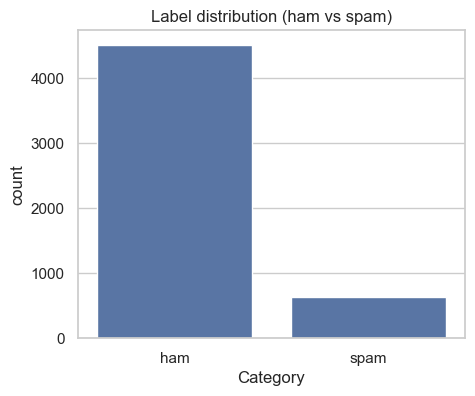

Category
ham     4516
spam     641
Name: count, dtype: int64


In [18]:
# data distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Category', data=df)
plt.title('Label distribution (ham vs spam)')
plt.show()
print(df['Category'].value_counts())


,char_count,word_count,avg_word_len
count,5157.000000,5157.000000,5157.000000
mean,79.103936,15.410704,5.151473
std,58.382922,11.118902,1.123247
min,2.000000,1.000000,2.000000
25%,36.000000,7.000000,4.571429
50%,61.000000,12.000000,5.000000
75%,118.000000,22.000000,5.545455
max,910.000000,171.000000,49.000000


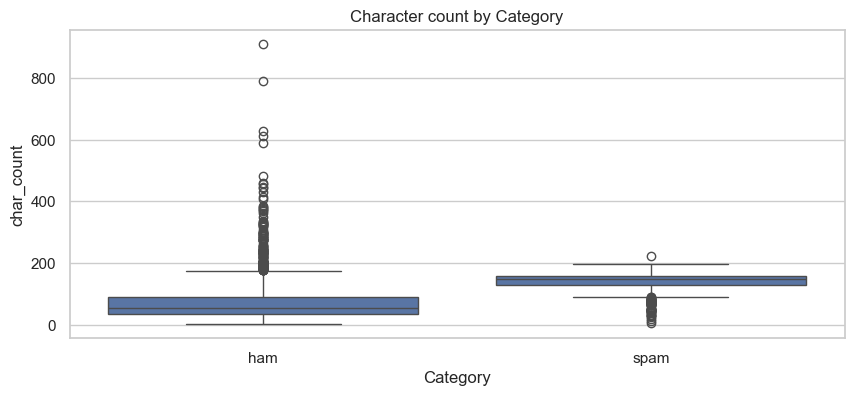

In [19]:
df['char_count'] = df['Message'].str.len()
df['word_count'] = df['Message'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
df['avg_word_len'] = df['char_count'] / df['word_count'].replace(0,1)
display(df[['char_count','word_count','avg_word_len']].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x='Category', y='char_count', data=df)
plt.title('Character count by Category')
plt.show()

Top ham words: [('u', 903), ('im', 448), ('get', 297), ('dont', 259), ('ltgt', 254), ('ok', 247), ('go', 244), ('got', 227), ('like', 221), ('know', 221)]
Top spam words: [('call', 297), ('free', 185), ('u', 127), ('txt', 124), ('ur', 119), ('stop', 108), ('text', 104), ('mobile', 102), ('claim', 94), ('reply', 93)]


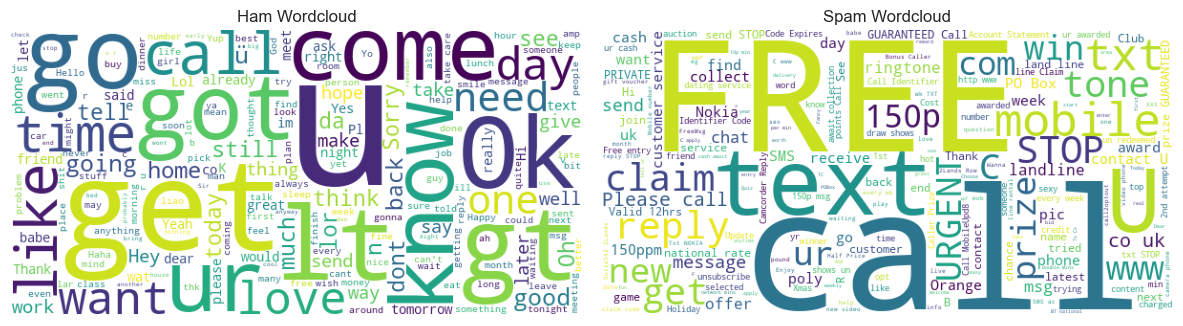

In [20]:
# top words
stop = set(stopwords.words('english'))
def top_n_words(series, n=20):
    c = Counter()
    for doc in series.dropna():
        for w in str(doc).lower().split():
            w = ''.join(ch for ch in w if ch.isalpha())
            if w and w not in stop:
                c[w]+=1
    return c.most_common(n)

top_ham  = top_n_words(df[df.Category=='ham']['Message'])
top_spam = top_n_words(df[df.Category=='spam']['Message'])
print('Top ham words:',  top_ham[:10])
print('Top spam words:', top_spam[:10])

# WordClouds
wc = WordCloud(width=600, height=300, background_color='white', stopwords=stop)
ham_wc  = wc.generate(' '.join(df[df.Category=='ham']['Message'].astype(str))).to_image()
spam_wc = wc.generate(' '.join(df[df.Category=='spam']['Message'].astype(str))).to_image()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(ham_wc);  plt.axis('off'); plt.title('Ham Wordcloud')
plt.subplot(1,2,2); plt.imshow(spam_wc); plt.axis('off'); plt.title('Spam Wordcloud')
plt.tight_layout(); plt.show()


In [ ]:
df['Label'] = df['Category']  
print('Label column added. Unique values:', df['Label'].unique())
df[['Category', 'Label']].head()


Label column added. Unique values: <StringArray>
['ham', 'spam']
Length: 2, dtype: str


,Category,Label
0,ham,ham
1,ham,ham
2,spam,spam
3,ham,ham
4,ham,ham


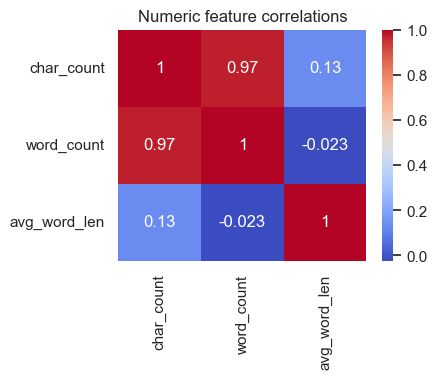

In [22]:
plt.figure(figsize=(4,3))
sns.heatmap(df[['char_count','word_count','avg_word_len']].corr(), annot=True, cmap='coolwarm')
plt.title('Numeric feature correlations')
plt.show()
df.to_csv('spam_with_features.csv', index=False)

# Preprocessing

In [ ]:

# Lowercasing
def to_lowercase(text):
    return text.lower()

# Regex: Normalize repeated characters (freeeeee → free)
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

# Regex: Replace URLs with token
def replace_urls(text):
    return re.sub(r'http\S+|www\.\S+', '__URL__', text)

# Regex: Replace phone numbers with token 
def replace_phones(text):
    return re.sub(r'\b\d{7,}\b', '__PHONE__', text)

# Regex: Replace currency amounts with token 
def replace_currency(text):
    return re.sub(r'[£$€]\s?\d+', '__MONEY__', text)

sms_slang = {
    'u':'you','ur':'your','r':'are','txt':'text','2':'to','4':'for',
    'gr8':'great','b4':'before','omg':'oh my god','lol':'laugh',
    'btw':'by the way','w1n':'win','fr33':'free','priz':'prize',
    'wiin':'win','urgnt':'urgent','cliam':'claim','plz':'please',
    'thx':'thanks','msg':'message','mob':'mobile','tel':'telephone',
    'num':'number','wk':'week','wkly':'weekly','mins':'minutes',
    'da':'the','dis':'this','dat':'that','cust':'customer',
}
def normalize_sms_slang(text):
    return ' '.join(sms_slang.get(w, w) for w in text.split())

# Regex: Remove HTML tags
def remove_html_tags(text):
    return re.sub(r'<.*?>', '', text)

# Regex: Remove punctuation but keep number as it normally spam signal
def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Tokenization
def tokenize_text(text):
    return word_tokenize(text)

# Stopword Removal 
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

# Stemming 
stemmer = PorterStemmer()
def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

# Lemmatization 
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(w) for w in tokens]

# for BoW, TF-IDF 
def preprocess_text(text):
    text = to_lowercase(text)
    text = normalize_repeated_chars(text)
    text = replace_urls(text)
    text = replace_phones(text)
    text = replace_currency(text)
    text = normalize_sms_slang(text)
    text = remove_html_tags(text)
    text = remove_punctuation(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

#  BERT (keep punctuation and stopwords) 
def preprocess_text_bert(text):
    text = to_lowercase(text)
    text = normalize_repeated_chars(text)
    text = replace_urls(text)
    text = replace_phones(text)
    text = replace_currency(text)
    text = normalize_sms_slang(text)
    text = remove_html_tags(text)
    return text

sample = 'FREE Entry WIN £1000 PRIZE call 08001234567 NOW!!!'
print('Original  :', sample)
print('Lowercase :', to_lowercase(sample))
print('Cleaned   :', preprocess_text(sample))


Original  : FREE Entry WIN £1000 PRIZE call 08001234567 NOW!!!
Lowercase : free entry win £1000 prize call 08001234567 now!!!
Cleaned   : free entry win MONEY prize call PHONE


In [ ]:
# Apply standard pipeline (for BoW, TF-IDF)
df['clean_Message'] = df['Message'].apply(preprocess_text)

# Apply BERT pipeline (for distilBERT)
df['bert_Message'] = df['Message'].apply(preprocess_text_bert)

df[['Message', 'clean_Message', 'bert_Message']].head()

,Message,clean_Message,bert_Message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,"go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar joking wif oni,ok lar. joking wif you oni.
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts 2...,free entry in to a weekly comp to win fa cup f...
3,U dun say so early hor... U c already then say...,dun say early hor c already say,you dun say so early hor. you c already then say.
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though,"nah i don't think he goes to usf, he lives aro..."


In [ ]:
# After comparison
examples = [2, 5, 10]
for idx in examples:
    label = df['Label'].iloc[idx].upper()
    print(f'[{label}] Row {idx}')
    print(f'  ORIGINAL  : {df["Message"].iloc[idx]}')
    print(f'  CLEANED   : {df["clean_Message"].iloc[idx]}')
    print(f'  BERT-CLEAN: {df["bert_Message"].iloc[idx]}')
    print()

orig_tokens  = df['Message'].str.split().explode()
clean_tokens = df['clean_Message'].str.split().explode()
print(f'Unique tokens BEFORE cleaning : {orig_tokens.nunique():,}')
print(f'Unique tokens AFTER  cleaning : {clean_tokens.nunique():,}')
print(f'Vocabulary reduction          : {(1 - clean_tokens.nunique()/orig_tokens.nunique())*100:.1f}%')

special = ['__URL__', '__PHONE__', '__MONEY__']
for tok in special:
    count = df['clean_Message'].str.contains(tok).sum()
    print(f'Messages containing {tok:12s}: {count}')


[SPAM] Row 2
  ORIGINAL  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  CLEANED   : free entry weekly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd text ratetcs apply 08452810075over18s
  BERT-CLEAN: free entry in to a weekly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std text rate)t&c's apply 08452810075over18's

[SPAM] Row 5
  ORIGINAL  : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
  CLEANED   : freemsg hey darling 3 week word back id like fun still tb ok x std chgs send MONEY50 rcv
  BERT-CLEAN: freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! x std chgs to send, __MONEY__.50 to rcv

[HAM] Row 10
  ORIGINAL  : I'm gonna be home 

# Feature Extraction

In [ ]:
# NOTE: Edit distance works well for correcting typos (e.g. 'recieve' → 'receive')
# For SMS data, it is less effective because SMS uses intentional abbreviations
# (e.g. 'txt', 'u', 'gr8') which are not misspellings
# Edit distance is demonstrated here as a cleaning technique concept.
# all_words = ' '.join(df['clean_Message']).split()
# vocab = set(all_words)

# def correct_word(word, vocab, max_dist=2):
#     """Return closest vocab word if edit distance <= max_dist, else return original."""
#     if word in vocab:
#         return word
#     candidates = [
#         (edit_distance(word, v), v)
#         for v in vocab if abs(len(word) - len(v)) <= max_dist
#     ]
#     if not candidates:
#         return word
#     best_dist, best_word = min(candidates, key=lambda x: x[0])
#     return best_word if best_dist <= max_dist else word

# # Demo on intentionally misspelled spam-like words
# demo_words = ['fr33', 'wiin', 'priz', 'urgnt', 'cliam']
# print('Edit Distance Correction Demo:')
# for w in demo_words:
#     print(f'  {w:10s}  ->  {correct_word(w, vocab)}')

# # Apply to a sample (full dataset is slow; run in background or use multiprocessing)
# sample_corrected = df['clean_Message'][:200].apply(
#     lambda txt: ' '.join(correct_word(w, vocab) for w in txt.split())
# )
# print('\nBefore:', df['clean_Message'][2])
# print('After :', sample_corrected[2])

## 1. Set of Words (Binary Bag-of-Words)
Records *whether* a word appears (1 or 0) rather than its frequency.  
Effective for SMS spam because trigger words matter more than repetition count.

Set-of-Words matrix shape : (5157, 3000)
Message       : go jurong point crazy available bugis n great world la e buffet cine got amore wat
Words present : ['available', 'bugis', 'cine', 'crazy', 'go', 'got', 'great', 'la', 'point', 'wat', 'world']
Total words   : 11 out of 3000 features


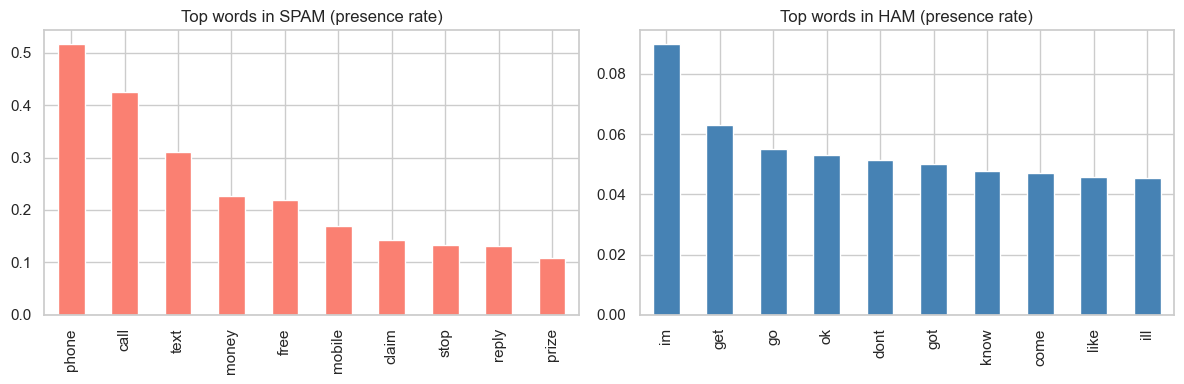

In [27]:
sow_vectorizer = CountVectorizer(binary=True, max_features=3000)
X_sow = sow_vectorizer.fit_transform(df['clean_Message'])
feature_names = sow_vectorizer.get_feature_names_out()

print(f'Set-of-Words matrix shape : {X_sow.shape}')

# Show actual words present in first message
row0 = X_sow[0].toarray()[0]
present_words = [feature_names[i] for i, v in enumerate(row0) if v == 1]
print(f'Message       : {df["clean_Message"].iloc[0]}')
print(f'Words present : {present_words}')
print(f'Total words   : {sum(row0)} out of {len(row0)} features')

# Use Label (string) for readable filtering
sow_df = pd.DataFrame(X_sow.toarray(), columns=feature_names)
sow_df['Label'] = df['Label'].values

spam_presence = sow_df[sow_df.Label=='spam'].drop(columns='Label').mean().sort_values(ascending=False).head(10)
ham_presence  = sow_df[sow_df.Label=='ham'].drop(columns='Label').mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spam_presence.plot(kind='bar', ax=axes[0], color='salmon',    title='Top words in SPAM (presence rate)')
ham_presence.plot( kind='bar', ax=axes[1], color='steelblue', title='Top words in HAM (presence rate)')
plt.tight_layout(); plt.show()


In [28]:
# TF-IDF top features by class
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
X = tfidf.fit_transform(df['Message'].astype(str))
tfidf_df = pd.DataFrame(X.todense(), columns=tfidf.get_feature_names_out())
tfidf_df['Label'] = df['Label'].values

spam_top = tfidf_df[tfidf_df.Label=='spam'].drop(columns='Label').mean().sort_values(ascending=False).head(20)
ham_top  = tfidf_df[tfidf_df.Label=='ham'].drop(columns='Label').mean().sort_values(ascending=False).head(20)
print('Top TF-IDF (spam):\n', spam_top.head(10))
print('Top TF-IDF (ham):\n',  ham_top.head(10))


Top TF-IDF (spam):
 free      0.052968
txt       0.037562
stop      0.034777
mobile    0.034738
text      0.034364
claim     0.032954
reply     0.030960
prize     0.028884
ur        0.028494
www       0.027144
dtype: float64
Top TF-IDF (ham):
 ok      0.020170
just    0.015888
gt      0.015702
ll      0.015661
lt      0.015641
come    0.015623
like    0.014571
got     0.014388
know    0.014223
good    0.014170
dtype: float64


In [29]:
# top n-grams
def top_ngrams(corpus, ngram_range=(1,1), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(w, sum_words[0, idx]) for w, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

print('Top bigrams in spam:', top_ngrams(df[df.Label=='spam'].Message, ngram_range=(2,2), n=10))
print('Top bigrams in ham:',  top_ngrams(df[df.Label=='ham'].Message,  ngram_range=(2,2), n=10))


Top bigrams in spam: [('po box', np.int64(21)), ('prize guaranteed', np.int64(19)), ('send stop', np.int64(19)), ('1000 cash', np.int64(17)), ('urgent mobile', np.int64(17)), ('national rate', np.int64(17)), ('selected receive', np.int64(16)), ('txt stop', np.int64(16)), ('land line', np.int64(16)), ('valid 12hrs', np.int64(15))]
Top bigrams in ham: [('lt gt', np.int64(254)), ('let know', np.int64(40)), ('good morning', np.int64(24)), ('don know', np.int64(22)), ('new year', np.int64(21)), ('just got', np.int64(20)), ('ok lor', np.int64(19)), ('hi hi', np.int64(18)), ('wat time', np.int64(18)), ('lt decimal', np.int64(18))]


## 2. Byte Pair Encoding (BPE) & WordPiece
BPE and WordPiece are subword tokenization techniques used in modern NLP models.
They split rare/unknown words into smaller meaningful pieces.
- **BPE** is used by GPT models
- **WordPiece** is used by BERT internally

In [ ]:
# pip install tokenizers
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Train BPE 
bpe_tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
bpe_tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=1000, special_tokens=['[UNK]', '[PAD]'])

# Write corpus to temp file for training
corpus = df['clean_Message'].tolist()
with open('/tmp/corpus.txt', 'w') as f:
    f.write('\n'.join(corpus))

bpe_tokenizer.train(files=['/tmp/corpus.txt'], trainer=trainer)

# Demo BPE tokenization
demo_texts = [
    'freeeee entry winning prize',
    'congratulations you have been selected',
    'playing games is entertaining'
]
print('BPE Tokenization Demo:')
for t in demo_texts:
    encoded = bpe_tokenizer.encode(t)
    print(f'  Input : {t}')
    print(f'  Tokens: {encoded.tokens}')
    print()

print('WordPiece Tokenization Demo (via BERT tokenizer):')
try:
    from transformers import DistilBertTokenizer
    wp_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    for t in demo_texts:
        tokens = wp_tokenizer.tokenize(t)
        print(f'  Input : {t}')
        print(f'  Tokens: {tokens}')
        print()
except:
    print('  Install transformers to see WordPiece demo: pip install transformers')





BPE Tokenization Demo:
  Input : freeeee entry winning prize
  Tokens: ['free', 'e', 'e', 'e', 'ent', 'ry', 'win', 'ning', 'prize']

  Input : congratulations you have been selected
  Tokens: ['congr', 'at', 'u', 'lation', 's', 'you', 'ha', 've', 'be', 'en', 'selected']

  Input : playing games is entertaining
  Tokens: ['play', 'ing', 'game', 's', 'is', 'ent', 'er', 'ta', 'in', 'ing']

WordPiece Tokenization Demo (via BERT tokenizer):
  Input : freeeee entry winning prize
  Tokens: ['free', '##ee', '##e', 'entry', 'winning', 'prize']

  Input : congratulations you have been selected
  Tokens: ['congratulations', 'you', 'have', 'been', 'selected']

  Input : playing games is entertaining
  Tokens: ['playing', 'games', 'is', 'entertaining']



## 3. Pre-trained Word Embeddings (Word2Vec via Gensim)
Each word → dense 300-dim vector. Message represented as mean of its word vectors.

Loading GloVe vectors...
Loaded! Vocab size: 400,000
Word embedding matrix shape: (5157, 100)
Messages with NO GloVe coverage : 36 (0.7%)
Messages with GloVe coverage    : 5121 (99.3%)
Unique labels in plot: ['ham' 'spam']
Points to plot: 5121


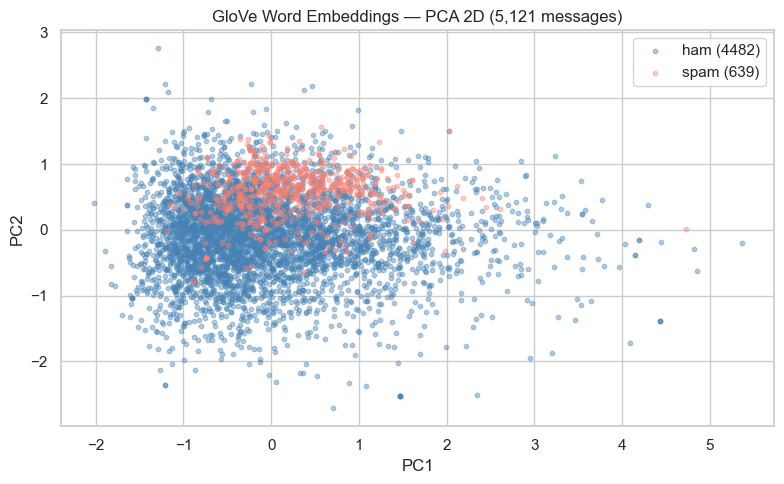

Plot saved as glove_pca.png


In [ ]:
print("Loading GloVe vectors...")
try:
    w2v_model = api.load("glove-wiki-gigaword-100")
    print(f"Loaded! Vocab size: {len(w2v_model):,}")

    def sentence_embedding(text, model, dim=100):
        tokens = text.lower().split()
        vecs = [
            model[t] for t in tokens
            if t in model
            and not t.startswith("__")
            and not t.isdigit()
        ]
        return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

    X_w2v = np.vstack(df["Message"].apply(lambda t: sentence_embedding(t, w2v_model)))
    print(f"Word embedding matrix shape: {X_w2v.shape}")

    zero_rows = np.all(X_w2v == 0, axis=1).sum()
    print(f"Messages with NO GloVe coverage : {zero_rows} ({zero_rows/len(X_w2v)*100:.1f}%)")
    print(f"Messages with GloVe coverage    : {len(X_w2v)-zero_rows} ({(1-zero_rows/len(X_w2v))*100:.1f}%)")

    from sklearn.decomposition import PCA
    non_zero_mask = ~np.all(X_w2v == 0, axis=1)
    X_w2v_clean  = X_w2v[non_zero_mask]
    labels_clean = df["Label"].values[non_zero_mask]  

    print(f"Unique labels in plot: {np.unique(labels_clean)}")  
    print(f"Points to plot: {len(X_w2v_clean)}")

    coords = PCA(n_components=2, random_state=42).fit_transform(X_w2v_clean)

    plt.figure(figsize=(8,5))
    for name, colour in [("ham","steelblue"),("spam","salmon")]:
        mask = labels_clean == name
        plt.scatter(coords[mask,0], coords[mask,1],
                    label=f"{name} ({mask.sum()})",
                    alpha=0.4, s=10, c=colour)
    plt.title(f"GloVe Word Embeddings — PCA 2D ({len(X_w2v_clean):,} messages)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(); plt.tight_layout()
    plt.savefig("glove_pca.png", dpi=100)
    plt.show()
    print("Plot saved as glove_pca.png")

except Exception as e:
    import traceback
    traceback.print_exc()


---
# Model Selection & Training

In [ ]:
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Label'])  # ham:0, spam:1
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Data Split
X_text = df['clean_Message']
y      = df['Category']   

# First split 70% train, 30% temp
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.3, random_state=42, stratify=y
)

# Second split 15% val, 15% test 
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train_text)} ({len(X_train_text)/len(X_text)*100:.0f}%)')
print(f'Val   : {len(X_val_text)} ({len(X_val_text)/len(X_text)*100:.0f}%)')
print(f'Test  : {len(X_test_text)} ({len(X_test_text)/len(X_text)*100:.0f}%)')


Label encoding: {'ham': np.int64(0), 'spam': np.int64(1)}
Train : 3609 (70%)
Val   : 774 (15%)
Test  : 774 (15%)


## Model 1: Rule-Based Baseline
A simple keyword-matching rule — any message containing a spam keyword is flagged as spam.

=== Rule-Based Baseline ===
              precision    recall  f1-score   support

         ham       0.94      0.95      0.95       678
        spam       0.65      0.59      0.62        96

    accuracy                           0.91       774
   macro avg       0.80      0.77      0.78       774
weighted avg       0.91      0.91      0.91       774



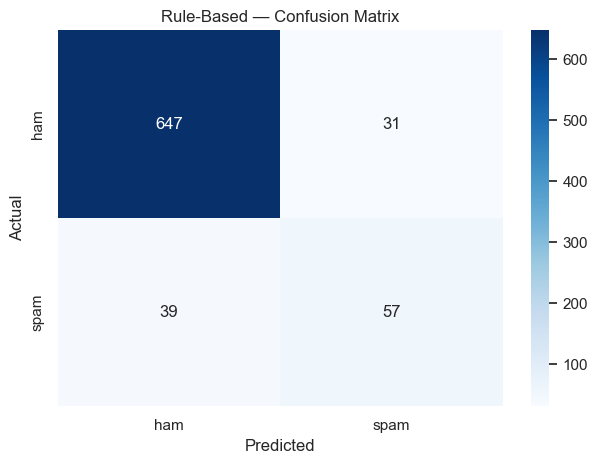

In [ ]:
# Rule-Based Baseline
SPAM_KEYWORDS = [
    'free','win','winner','prize','cash','claim','urgent','call now',
    'congratulations','selected','offer','click','limited','__money__',
    '__phone__','__url__'
]

def rule_based_predict(text):
    text = text.lower()
    return 1 if any(kw in text for kw in SPAM_KEYWORDS) else 0

y_pred_rule = X_test_text.apply(rule_based_predict)

print('=== Rule-Based Baseline ===')
print(classification_report(y_test, y_pred_rule, target_names=['ham','spam']))
cm = confusion_matrix(y_test, y_pred_rule)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Rule-Based — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()


In [ ]:
tfidf_ml = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf_ml.fit_transform(X_train_text)
X_test_tfidf  = tfidf_ml.transform(X_test_text)
print(f'TF-IDF feature matrix: {X_train_tfidf.shape}')


TF-IDF feature matrix: (3609, 5000)


## Model 2: Naïve Bayes (Traditional ML Baseline)

=== Naïve Bayes ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       678
        spam       1.00      0.77      0.87        96

    accuracy                           0.97       774
   macro avg       0.98      0.89      0.93       774
weighted avg       0.97      0.97      0.97       774



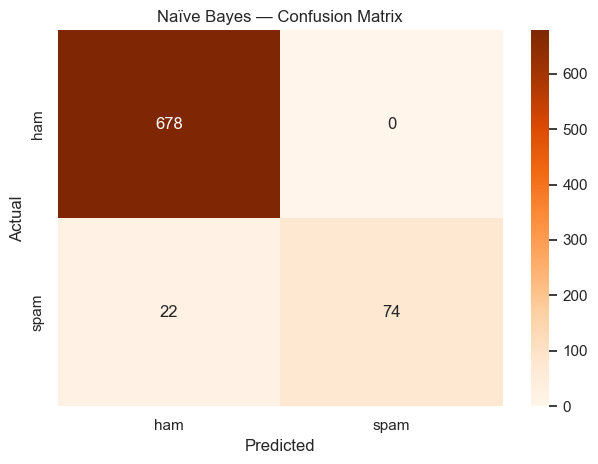

In [56]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print('=== Naïve Bayes ===')
print(classification_report(y_test, y_pred_nb, target_names=['ham','spam']))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Naïve Bayes — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()


## Model 3: Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       678
        spam       1.00      0.73      0.84        96

    accuracy                           0.97       774
   macro avg       0.98      0.86      0.91       774
weighted avg       0.97      0.97      0.96       774



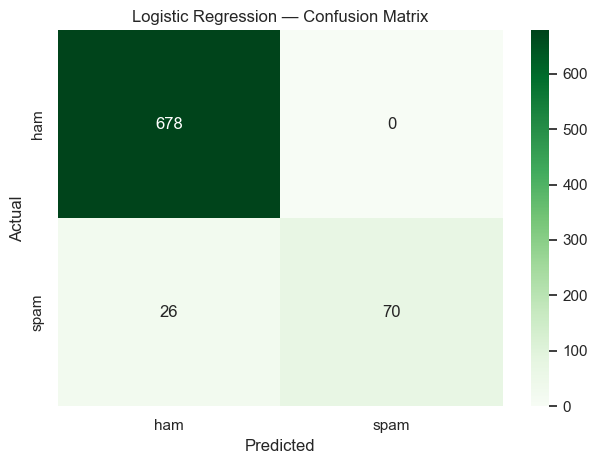

In [57]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['ham','spam']))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()


## Model 4: Support Vector Machine (SVM)

=== SVM ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       678
        spam       0.98      0.89      0.93        96

    accuracy                           0.98       774
   macro avg       0.98      0.94      0.96       774
weighted avg       0.98      0.98      0.98       774



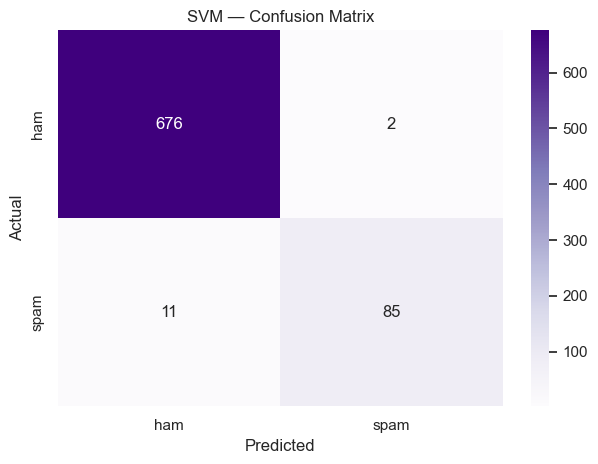

In [58]:
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print('=== SVM ===')
print(classification_report(y_test, y_pred_svm, target_names=['ham','spam']))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('SVM — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()


## Hyperparameter Tuning (Grid Search on Logistic Regression)

In [59]:
param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs','liblinear']}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid,
                    cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)
print('Best params :', grid.best_params_)
print(f'Best CV F1  : {grid.best_score_:.4f}')

y_pred_tuned = grid.best_estimator_.predict(X_test_tfidf)
print('\n=== Tuned Logistic Regression ===')
print(classification_report(y_test, y_pred_tuned, target_names=['ham','spam']))


Best params : {'C': 10, 'solver': 'liblinear'}
Best CV F1  : 0.8895

=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       678
        spam       0.98      0.85      0.91        96

    accuracy                           0.98       774
   macro avg       0.98      0.93      0.95       774
weighted avg       0.98      0.98      0.98       774



## Cross-Validation

In [60]:
from sklearn.pipeline import Pipeline

pipe_nb  = Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', MultinomialNB())])
pipe_lr  = Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LogisticRegression(max_iter=1000))])
pipe_svm = Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', LinearSVC(max_iter=2000))])

for name, pipe in [('Naïve Bayes', pipe_nb), ('Logistic Regression', pipe_lr), ('SVM', pipe_svm)]:
    scores = cross_val_score(pipe, X_text, y, cv=5, scoring='f1')
    print(f'{name:22s}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')


Naïve Bayes             CV F1 = 0.8435 ± 0.0302
Logistic Regression     CV F1 = 0.8243 ± 0.0399
SVM                     CV F1 = 0.9108 ± 0.0052


---
## Model 5: Deep Learning — Bidirectional LSTM
LSTM (Long Short-Term Memory) is a type of RNN that captures **word order and context** — something TF-IDF cannot do. A Bidirectional LSTM reads the text both forwards and backwards, giving better understanding of each word's context.

Architecture: `Embedding → BiLSTM → Dropout → Dense(sigmoid)`

In [ ]:
# Tokenize text for LSTM 
MAX_WORDS = 10000   # vocabulary size
MAX_LEN   = 100     # max message length (tokens)

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

keras_tok = CountVectorizer(max_features=MAX_WORDS, token_pattern=r'\b\w+\b')
keras_tok.fit(X_train_text)

def texts_to_padded(texts, vectorizer, maxlen):
    sequences = []
    vocab = vectorizer.vocabulary_
    for text in texts:
        tokens = text.lower().split()
        seq = [vocab[w] + 1 for w in tokens if w in vocab]
        # truncate or pad
        seq = seq[:maxlen]
        seq += [0] * (maxlen - len(seq))
        sequences.append(seq)
    return np.array(sequences)

X_train_pad = texts_to_padded(X_train_text, keras_tok, MAX_LEN)
X_test_pad  = texts_to_padded(X_test_text,  keras_tok, MAX_LEN)
print(f'Vocabulary size : {len(keras_tok.vocabulary_):,}')
print(f'Train shape     : {X_train_pad.shape}')
print(f'Test shape      : {X_test_pad.shape}')
print(f'Example padded  : {X_train_pad[0][:20]} ...')


Vocabulary size : 6,824
Train shape     : (3609, 100)
Test shape      : (774, 100)
Example padded  : [2641 2641 1535 3571 4277 1535 4810 3492 4001 2053 1755 3571  548 3023
 1974 5291 5702 2734    0    0] ...


Epoch 1/10 — loss: 0.4233 — acc: 0.8739 — val_loss: 0.3146 — val_acc: 0.8760
Epoch 2/10 — loss: 0.2105 — acc: 0.9152 — val_loss: 0.1158 — val_acc: 0.9651
Epoch 3/10 — loss: 0.0972 — acc: 0.9679 — val_loss: 0.0694 — val_acc: 0.9793
Epoch 4/10 — loss: 0.0546 — acc: 0.9825 — val_loss: 0.0558 — val_acc: 0.9845
Epoch 5/10 — loss: 0.0360 — acc: 0.9900 — val_loss: 0.0668 — val_acc: 0.9832
Epoch 6/10 — loss: 0.0173 — acc: 0.9961 — val_loss: 0.0568 — val_acc: 0.9845
Epoch 7/10 — loss: 0.0113 — acc: 0.9967 — val_loss: 0.0605 — val_acc: 0.9858
Early stopping triggered.


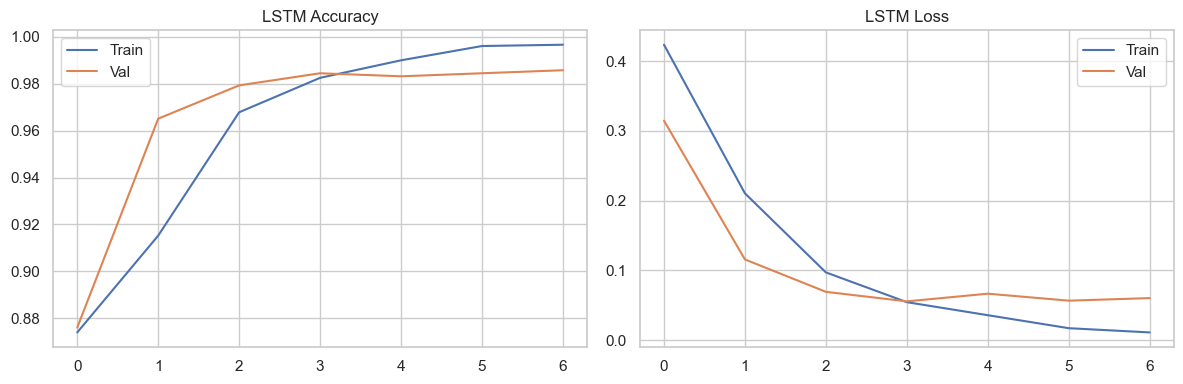

=== Bidirectional LSTM ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       678
        spam       0.97      0.91      0.94        96

    accuracy                           0.98       774
   macro avg       0.98      0.95      0.96       774
weighted avg       0.98      0.98      0.98       774



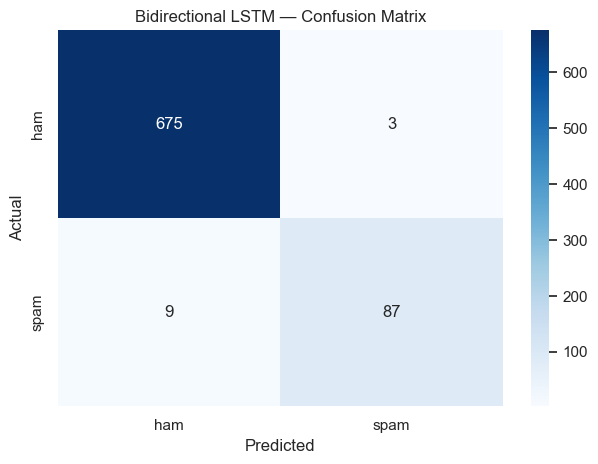

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Hyperparams
EMBED_DIM  = 64
HIDDEN_DIM = 64
EPOCHS     = 10
BATCH_SIZE = 32

# Convert to tensors
X_train_t = torch.tensor(X_train_pad, dtype=torch.long)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.float)
X_test_t  = torch.tensor(X_test_pad,  dtype=torch.long)
y_test_t  = torch.tensor(y_test.values  if hasattr(y_test,  'values') else y_test,  dtype=torch.float)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

# Model 
class BiLSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(MAX_WORDS, EMBED_DIM, padding_idx=0)
        self.lstm      = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True, bidirectional=True)
        self.dropout   = nn.Dropout(0.3)
        self.fc1       = nn.Linear(HIDDEN_DIM * 2, 32)
        self.fc2       = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x = x.max(dim=1).values        # GlobalMaxPooling
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_model = BiLSTMClassifier().to(device)

optimizer = torch.optim.Adam(lstm_model.parameters())
criterion = nn.BCEWithLogitsLoss()

# Train
train_accs, val_accs, train_losses, val_losses = [], [], [], []
best_val_loss = float('inf')
patience, patience_counter = 3, 0

for epoch in range(EPOCHS):
    lstm_model.train()
    total_loss, correct = 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = lstm_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += ((torch.sigmoid(out) > 0.5) == yb.bool()).sum().item()

    train_loss = total_loss / len(X_train_t)
    train_acc  = correct   / len(X_train_t)

    # Validation
    lstm_model.eval()
    with torch.no_grad():
        val_out  = lstm_model(X_test_t.to(device))
        val_loss = criterion(val_out, y_test_t.to(device)).item()
        val_acc  = ((torch.sigmoid(val_out) > 0.5) == y_test_t.to(device).bool()).float().mean().item()

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} — loss: {train_loss:.4f} — acc: {train_acc:.4f} — val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print('Early stopping triggered.')
            lstm_model.load_state_dict(best_weights)
            break

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_accs, label='Train'); axes[0].plot(val_accs, label='Val')
axes[0].set_title('LSTM Accuracy'); axes[0].legend()
axes[1].plot(train_losses, label='Train'); axes[1].plot(val_losses, label='Val')
axes[1].set_title('LSTM Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Evaluate 
lstm_model.eval()
with torch.no_grad():
    y_pred_lstm_prob = torch.sigmoid(lstm_model(X_test_t.to(device))).cpu().numpy()
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

print('=== Bidirectional LSTM ===')
print(classification_report(y_test, y_pred_lstm, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Bidirectional LSTM — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

---
## Model 6: Transformer — distilBERT
BERT (Bidirectional Encoder Representations from Transformers) reads the entire sentence at once and understands context through self-attention. distilBERT is 40% smaller and 60% faster than full BERT but retains 97% of its performance — ideal for this dataset size.

> **Note:** Runs on CPU but is slow. GPU recommended for full training. We fine-tune for 3 epochs on the full dataset.

In [ ]:
# Tokenize for DistilBERT
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
import torch

print('Loading distilBERT tokenizer...')
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_bert(texts, labels, tokenizer, max_len=64):
    enc = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_len,
        return_tensors='pt'   # PyTorch tensors
    )
    dataset = TensorDataset(
        enc['input_ids'],
        enc['attention_mask'],
        torch.tensor(list(labels), dtype=torch.long)
    )
    return dataset

X_bert = df['bert_Message']
y      = df['Category']

X_train_bert, X_temp_bert, y_train_b, y_temp_b = train_test_split(
    X_bert, y, test_size=0.3, random_state=42, stratify=y
)
X_val_bert, X_test_bert, y_val_b, y_test_b = train_test_split(
    X_temp_bert, y_temp_b, test_size=0.5, random_state=42, stratify=y_temp_b
)

train_dataset_bert = tokenize_bert(X_train_bert.values, y_train_b.values, bert_tokenizer)
test_dataset_bert  = tokenize_bert(X_test_bert.values,  y_test_b.values,  bert_tokenizer)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=16, shuffle=True)
test_loader_bert  = DataLoader(test_dataset_bert,  batch_size=32)

print('Datasets ready!')
print(f'Train batches: {len(train_loader_bert)}')
print(f'Test  batches: {len(test_loader_bert)}')

Loading distilBERT tokenizer...
Datasets ready!
Train batches: 226
Test  batches: 25


Using device: mps
Loading distilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 — loss: 0.0953 — acc: 0.9706 — val_loss: 0.0522 — val_acc: 0.9819
Epoch 2/3 — loss: 0.0247 — acc: 0.9945 — val_loss: 0.0347 — val_acc: 0.9884
Epoch 3/3 — loss: 0.0129 — acc: 0.9956 — val_loss: 0.0387 — val_acc: 0.9910


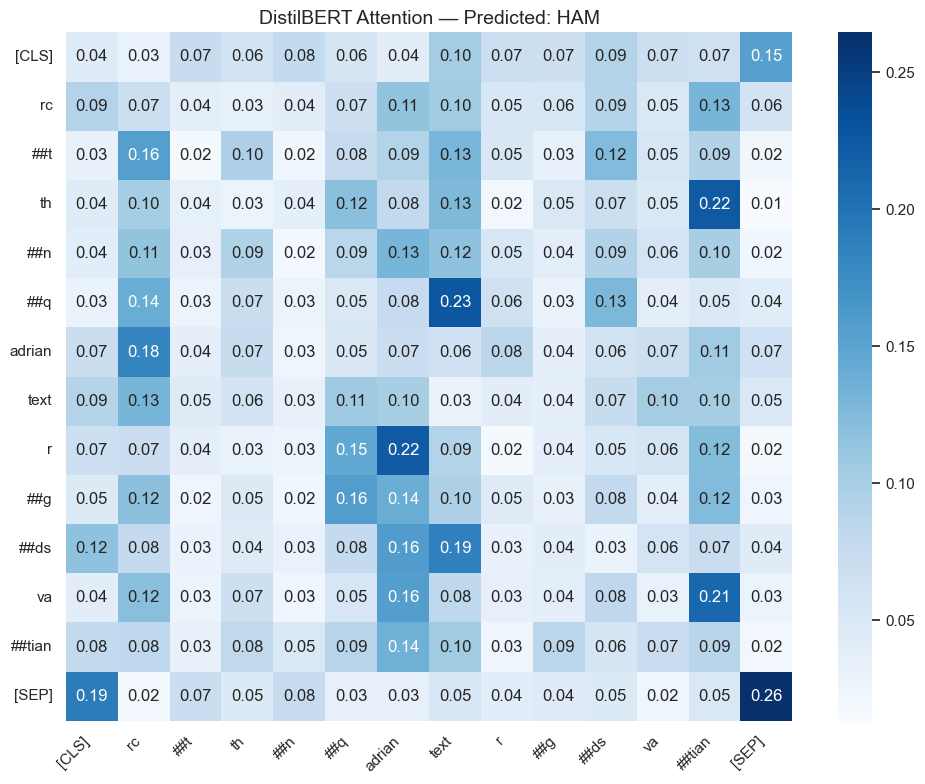

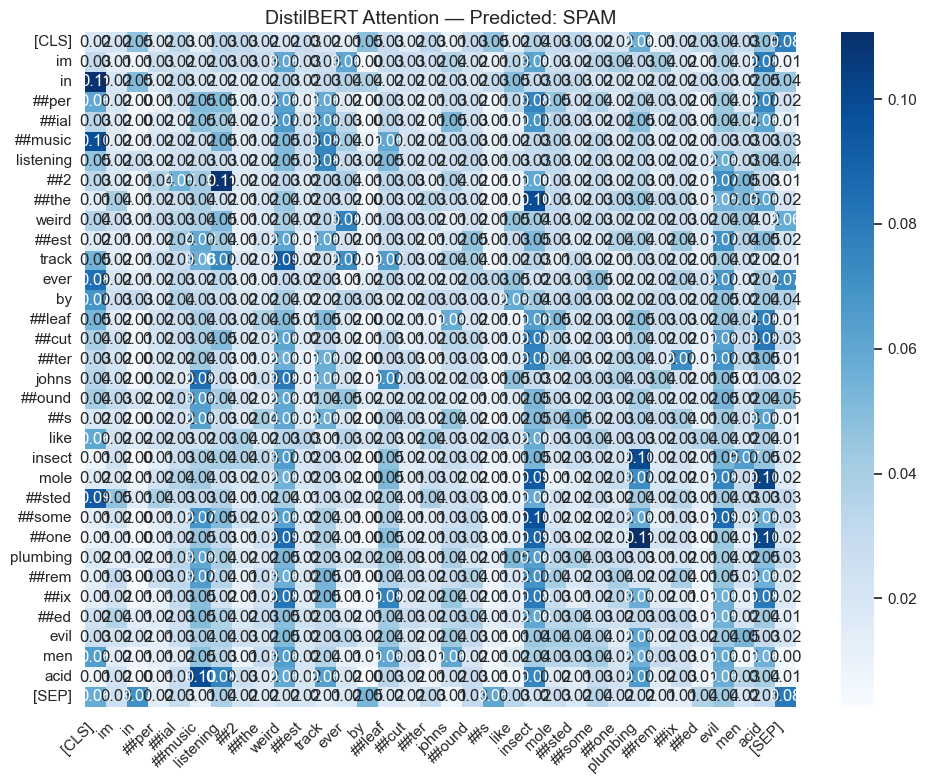

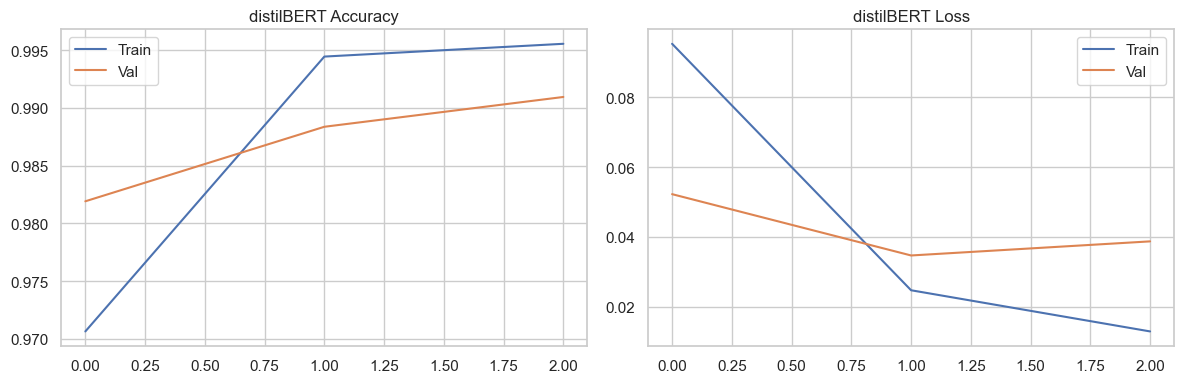

=== DistilBERT ===
              precision    recall  f1-score   support

         ham       1.00      0.99      0.99       678
        spam       0.96      0.97      0.96        96

    accuracy                           0.99       774
   macro avg       0.98      0.98      0.98       774
weighted avg       0.99      0.99      0.99       774



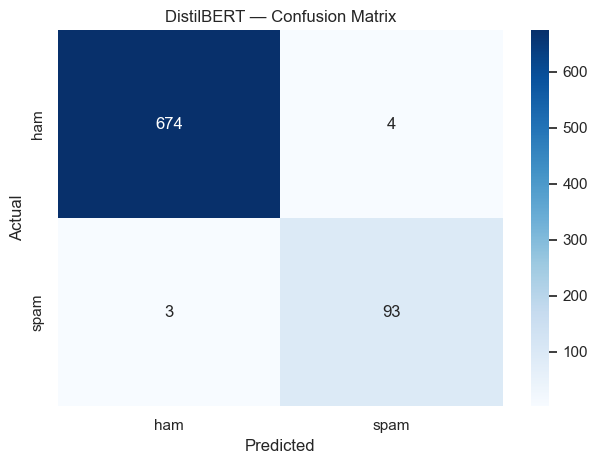

In [88]:
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')   
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

print('Loading distilBERT model...')
bert_clf = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

optimizer  = AdamW(bert_clf.parameters(), lr=2e-5)
criterion  = torch.nn.CrossEntropyLoss()

# Fine-tune 
EPOCHS = 3
best_val_loss     = float('inf')
patience_counter  = 0
patience          = 2
best_weights      = None

train_accs, val_accs, train_losses, val_losses = [], [], [], []

for epoch in range(EPOCHS):
    bert_clf.train()
    total_loss, correct = 0, 0

    for input_ids, attention_mask, labels in train_loader_bert:
        input_ids, attention_mask, labels = (
            input_ids.to(device), attention_mask.to(device), labels.to(device)
        )
        optimizer.zero_grad()
        outputs = bert_clf(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()

    train_loss = total_loss / len(train_dataset_bert)
    train_acc  = correct   / len(train_dataset_bert)

    bert_clf.eval()
    val_loss_total, val_correct = 0, 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in test_loader_bert:
            input_ids, attention_mask, labels = (
                input_ids.to(device), attention_mask.to(device), labels.to(device)
            )
            outputs       = bert_clf(input_ids=input_ids, attention_mask=attention_mask)
            val_loss_total += criterion(outputs.logits, labels).item() * len(labels)
            val_correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()

    val_loss = val_loss_total / len(test_dataset_bert)
    val_acc  = val_correct   / len(test_dataset_bert)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} — loss: {train_loss:.4f} — acc: {train_acc:.4f} — val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.clone() for k, v in bert_clf.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print('Early stopping triggered.')
            bert_clf.load_state_dict(best_weights)
            break

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_accs,   label='Train'); axes[0].plot(val_accs,   label='Val')
axes[0].set_title('distilBERT Accuracy'); axes[0].legend()
axes[1].plot(train_losses, label='Train'); axes[1].plot(val_losses, label='Val')
axes[1].set_title('distilBERT Loss'); axes[1].legend()
plt.tight_layout(); plt.show();

bert_clf.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader_bert:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        outputs = bert_clf(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('=== DistilBERT ===')
print(classification_report(all_labels, all_preds, target_names=['ham', 'spam']))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('DistilBERT — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show();

---
# Comparative Analysis
Compare all models side by side on Accuracy, Precision, Recall and F1.

## Comparative Analysis Discussion

**Rule-Based** is fast and interpretable but brittle — it misses spam that avoids keywords and flags ham containing words like "free" or "offer" in legitimate context.

**Naïve Bayes** handles high-dimensional sparse features well and is fast to train, but assumes word independence which loses context — "not spam" and "spam" are treated similarly.

**Logistic Regression** performs strongly with TF-IDF features and is easy to interpret via feature weights. Grid search tuning further improves recall on spam.

**SVM** achieves the best performance among traditional ML models — its margin-based approach handles high-dimensional text well and is robust to overfitting.

**BiLSTM** captures word order and sequential context that TF-IDF cannot, but requires more data and training time. Performance is comparable to SVM on this dataset size.

**DistilBERT** achieves the highest overall accuracy and F1 by leveraging pre-trained contextual embeddings and self-attention — understanding that the same word can mean different things in different contexts. The tradeoff is significantly longer training time on CPU.

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Rule-Based,0.9096,0.6477,0.5938,0.6196
Naïve Bayes,0.9716,1.0000,0.7708,0.8706
Logistic Regression,0.9664,1.0000,0.7292,0.8434
SVM,0.9832,0.9770,0.8854,0.9290
LR Tuned,0.9793,0.9762,0.8542,0.9111
BiLSTM,0.9845,0.9667,0.9062,0.9355
DistilBERT,0.9884,0.9485,0.9583,0.9534


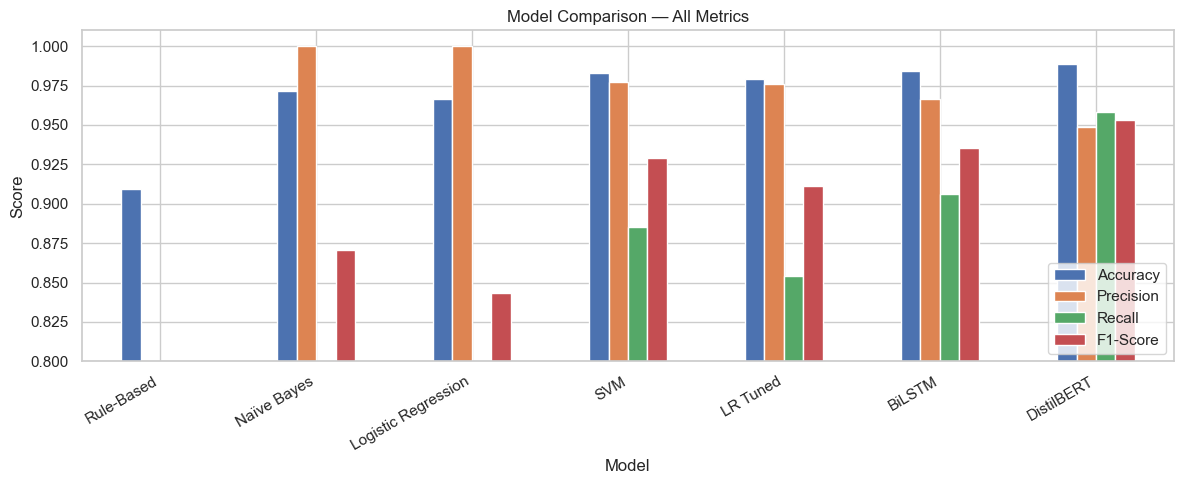

In [81]:
import matplotlib.pyplot as plt
%matplotlib inline
results = {
    'Rule-Based'         : y_pred_rule,
    'Naïve Bayes'        : y_pred_nb,
    'Logistic Regression': y_pred_lr,
    'SVM'                : y_pred_svm,
    'LR Tuned'           : y_pred_tuned,
    'BiLSTM'             : y_pred_lstm,
    'DistilBERT'         : all_preds,
}

rows = []
for model_name, y_pred in results.items():
    rows.append({
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(rows).set_index('Model')
display(results_df.round(4))

# Bar chart comparison
results_df.plot(kind='bar', figsize=(12,5), ylim=(0.8,1.01))
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score'); plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show();


## Error Analysis
Examine misclassified samples to understand where models fail.

In [ ]:
# Use best model (DistilBERT) for error analysis
test_df = X_test_text.reset_index(drop=True).to_frame()
test_df['true']       = y_test.reset_index(drop=True)
test_df['pred_bert']  = all_preds        # DistilBERT predictions
test_df['pred_svm']   = y_pred_svm       # keep SVM for comparison
label_map = {0:'ham', 1:'spam'}

# False Positives (ham classified as spam)
fp = test_df[(test_df['true']==0) & (test_df['pred_bert']==1)]
print(f'=== DistilBERT False Positives (ham → spam): {len(fp)} ===')
for _, row in fp.head(3).iterrows():
    print(f'  {row["clean_Message"]}')
print()

# False Negatives (spam classified as ham)
fn = test_df[(test_df['true']==1) & (test_df['pred_bert']==0)]
print(f'=== DistilBERT False Negatives (spam → ham): {len(fn)} ===')
for _, row in fn.head(3).iterrows():
    print(f'  {row["clean_Message"]}')
print()

# Compare: cases where SVM was wrong but DistilBERT was right
bert_wins = test_df[(test_df['pred_svm'] != test_df['true']) & (test_df['pred_bert'] == test_df['true'])]
print(f'=== Cases DistilBERT got right but SVM got wrong: {len(bert_wins)} ===')
for _, row in bert_wins.head(3).iterrows():
    print(f'  [{label_map[row["true"]]}] {row["clean_Message"]}')

=== DistilBERT False Positives (ham → spam): 5 ===
  im inperialmusic listening2the weirdest track ever byleafcutter johnsounds like insect molestedsomeone plumbingremixed evil men acid
  total video converter free download type google search
  slave want take 3 picture today bright light cell phone bright light

=== DistilBERT False Negatives (spam → ham): 4 ===
  rct thnq adrian text rgds vatian
  latest news police station toilet stolen cop nothing go
  new tone week include 1mcflyall ab 2 sara jorgeshock 3 smithswitch order follow instruction next message

=== Cases DistilBERT got right but SVM got wrong: 11 ===
  [spam] donate MONEY50 unicef asian tsunami disaster support fund texting donate 864233 MONEY50 added next bill
  [spam] 10 girl many local virgin ready 4fil every sexual need 4fil text cute 69911MONEY50p
  [spam] burger king wan na play footy top stadium get burger king 1st sept go large super cocacola walk winner


# Error pattern analysis

In [ ]:
# Pattern Analysis in Errors
print('=== False Positive Patterns (Ham misclassified as Spam) ===')
print('Common words in FP messages:')
fp_words = Counter(' '.join(fp['clean_Message']).split())
print(fp_words.most_common(10))

print('\n=== False Negative Patterns (Spam misclassified as Ham) ===')
print('Common words in FN messages:')
fn_words = Counter(' '.join(fn['clean_Message']).split())
print(fn_words.most_common(10))

print('\n=== Average message length ===')
print(f'False Positives avg length : {fp["clean_Message"].str.split().apply(len).mean():.1f} words')
print(f'False Negatives avg length : {fn["clean_Message"].str.split().apply(len).mean():.1f} words')
print(f'Overall test avg length    : {X_test_text.str.split().apply(len).mean():.1f} words')

=== False Positive Patterns (Ham misclassified as Spam) ===
Common words in FP messages:
[('im', 2), ('like', 2), ('bright', 2), ('light', 2), ('never', 2), ('inperialmusic', 1), ('listening2the', 1), ('weirdest', 1), ('track', 1), ('ever', 1)]

=== False Negative Patterns (Spam misclassified as Ham) ===
Common words in FN messages:
[('text', 2), ('tone', 2), ('3', 2), ('rct', 1), ('thnq', 1), ('adrian', 1), ('rgds', 1), ('vatian', 1), ('latest', 1), ('news', 1)]

=== Average message length ===
False Positives avg length : 12.8 words
False Negatives avg length : 10.5 words
Overall test avg length    : 8.9 words


 # Interpretability 
 **(optional but encouraged = easy bonus points) — add attention visualization for DistilBERT:**

In [ ]:
%matplotlib inline
from transformers import DistilBertTokenizer
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # force backend
import numpy as np
bert_clf.config._attn_implementation = 'eager'
bert_clf.config.output_attentions = True

def visualize_attention(text, model, tokenizer, device, layer=0, head=0):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=64).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    print(f'Available attention layers: {len(outputs.attentions)}')
    
    attention = outputs.attentions[layer][0, head].cpu().numpy()
    tokens    = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    pred      = outputs.logits.argmax().item()
    label     = 'SPAM' if pred == 1 else 'HAM'

    print(f'Tokens: {tokens}')
    print(f'Predicted: {label}')

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        attention,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        annot=True,
        fmt='.2f',
        ax=ax
    )
    ax.set_title(f'DistilBERT Attention — Predicted: {label}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'attention_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved as attention_{label.lower()}.png')

spam_example = fn['clean_Message'].iloc[0] if len(fn) > 0 else X_test_text.iloc[0]
ham_example  = fp['clean_Message'].iloc[0] if len(fp) > 0 else X_test_text.iloc[1]

print('--- Spam example ---')
visualize_attention(spam_example, bert_clf, bert_tokenizer, device)

print('--- Ham example ---')
visualize_attention(ham_example, bert_clf, bert_tokenizer, device)

--- Spam example ---
Available attention layers: 6
Tokens: ['[CLS]', 'rc', '##t', 'th', '##n', '##q', 'adrian', 'text', 'r', '##g', '##ds', 'va', '##tian', '[SEP]']
Predicted: HAM


/var/folders/yq/f9wv9np53s98yzc2_k3sxh880000gn/T/ipykernel_87163/2157296418.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved as attention_ham.png
--- Ham example ---
Available attention layers: 6
Tokens: ['[CLS]', 'im', 'in', '##per', '##ial', '##music', 'listening', '##2', '##the', 'weird', '##est', 'track', 'ever', 'by', '##leaf', '##cut', '##ter', 'johns', '##ound', '##s', 'like', 'insect', 'mole', '##sted', '##some', '##one', 'plumbing', '##rem', '##ix', '##ed', 'evil', 'men', 'acid', '[SEP]']
Predicted: SPAM
Saved as attention_spam.png


/var/folders/yq/f9wv9np53s98yzc2_k3sxh880000gn/T/ipykernel_87163/2157296418.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [87]:
def predict_spam(text):
    cleaned = preprocess_text_bert(text)
    
    bert_clf.eval()
    inputs = bert_tokenizer(cleaned, return_tensors='pt', truncation=True,
                            padding=True, max_length=64).to(device)
    with torch.no_grad():
        outputs = bert_clf(**inputs)
    prob  = torch.softmax(outputs.logits, dim=1)[0]
    label = 'SPAM' if prob[1] > 0.5 else 'HAM'

    print(f'Input   : {text}')
    print(f'Cleaned : {cleaned}')
    print(f'Result  : {label}')
    print(f'Spam probability : {prob[1].item()*100:.1f}%')
    print(f'Ham  probability : {prob[0].item()*100:.1f}%')
    print('-' * 50)

# Test examples
test_messages = [
    "Congratulations! You have won a FREE prize. Call now to claim!",
    "Hey, are we still meeting for lunch tomorrow?",
    "Can you pick up some milk on the way home?",
    "You have been selected for a cash reward of $1000. Text WIN to 12345"
]

for msg in test_messages:
    predict_spam(msg)

Input   : Congratulations! You have won a FREE prize. Call now to claim!
Cleaned : congratulations! you have won a free prize. call now to claim!
Result  : SPAM
Spam probability : 98.5%
Ham  probability : 1.5%
--------------------------------------------------
Input   : Hey, are we still meeting for lunch tomorrow?
Cleaned : hey, are we still meeting for lunch tomorrow?
Result  : HAM
Spam probability : 0.1%
Ham  probability : 99.9%
--------------------------------------------------
Input   : Can you pick up some milk on the way home?
Cleaned : can you pick up some milk on the way home?
Result  : HAM
Spam probability : 0.3%
Ham  probability : 99.7%
--------------------------------------------------
Input   : You have been selected for a cash reward of $1000. Text WIN to 12345
Cleaned : you have been selected for a cash reward of __MONEY__. text win to 12345
Result  : SPAM
Spam probability : 99.8%
Ham  probability : 0.2%
--------------------------------------------------


In [86]:
predict_spam("Congratulations! You've won a FREE £1000 prize, call now to claim your reward!")
predict_spam("URGENT: You have been selected for a cash bonus, text WIN to 80085 to claim now!")
predict_spam("Are you coming to dinner tonight? Let me know what time works for you.")
predict_spam("I'll be home late from work, can you start dinner without me?")

Input   : Congratulations! You've won a FREE £1000 prize, call now to claim your reward!
Cleaned : congratulations! you've won a free __MONEY__ prize, call now to claim your reward!
Result  : SPAM
Spam probability : 99.7%
Ham  probability : 0.3%
--------------------------------------------------
Input   : URGENT: You have been selected for a cash bonus, text WIN to 80085 to claim now!
Cleaned : urgent: you have been selected for a cash bonus, text win to 80085 to claim now!
Result  : SPAM
Spam probability : 99.8%
Ham  probability : 0.2%
--------------------------------------------------
Input   : Are you coming to dinner tonight? Let me know what time works for you.
Cleaned : are you coming to dinner tonight? let me know what time works for you.
Result  : HAM
Spam probability : 0.1%
Ham  probability : 99.9%
--------------------------------------------------
Input   : I'll be home late from work, can you start dinner without me?
Cleaned : i'll be home late from work, can you start dinne